# FINAL PROJECT 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

### CROSS-SECTION (95:05 MMI)

2026-03-31 17:48:12.171 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e77b48d39e0c99ca.npz.
Fracción TE: [0.99999614 0.99998448]


array([2.84963348+2.07676919e-05j, 2.84653459+2.08000043e-05j])

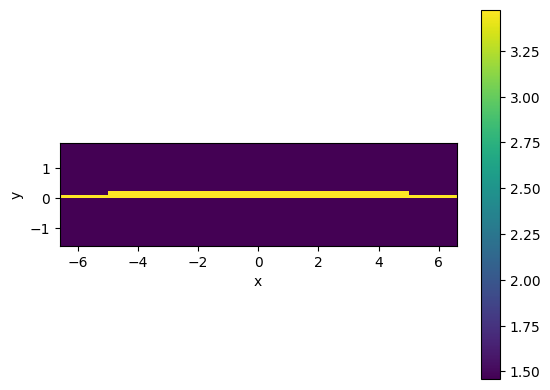

In [2]:

mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=220 * nm, # MMI Body height 
    slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.2, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [3]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

254.29395076834993


Observamos que el índice efectivo no es igual que el del paper. Sin embargo, lo damos como bueno porque la diferencia entre ellos sí que lo es. Se ha intentado hacer un análisis de grid pero computacionalmente era muy costoso y no se ha podido ejecutar de forma correcta. De momento continuamos con estos valores. 

[20. 30. 40. 50. 60. 70. 80.]


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

17:54:15 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-03-31 17:54:15.112 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_71e8da3c5bd5d306.npz.
2026-03-31 17:54:15.120 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3f83cc157ea67da5.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 17:54:35.522 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_24f14b21426474d0.npz.
2026-03-31 17:54:35.539 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cb2269b83fbb67f9.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 17:55:20.355 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9cef4575e772b41b.npz.
2026-03-31 17:55:20.391 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d3db2e7d6675bed4.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 17:57:52.269 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_831121f111c79fd8.npz.


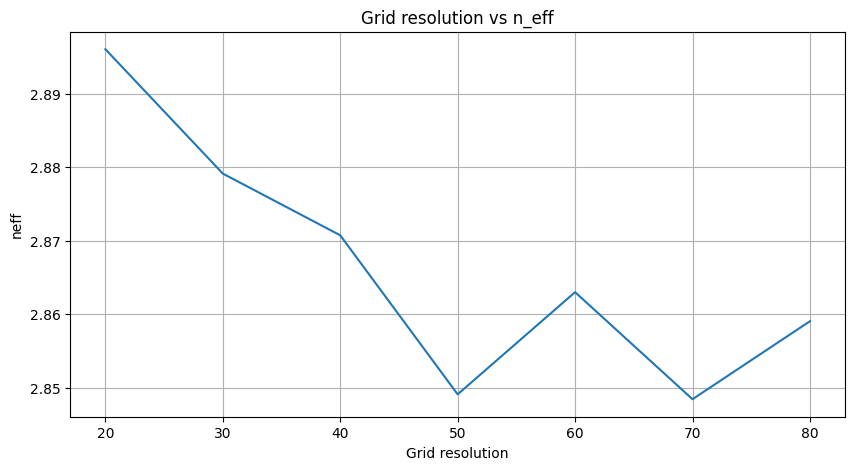

In [3]:
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []
print(grid_resolution)

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=220 * nm, # MMI Body height 
        slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

[20. 30. 40. 50. 60. 70. 80.]
2026-03-31 18:10:36.105 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_36f642496594bd14.npz.
2026-03-31 18:10:36.110 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_da9332bfc5aaa1ad.npz.
2026-03-31 18:10:36.114 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_43ce73feed05b202.npz.
2026-03-31 18:10:36.119 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cb2269b83fbb67f9.npz.
2026-03-31 18:10:36.122 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bd7260dc4484a1a3.npz.
2026-03-31 18:10:36.126 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1ea9ce0db219128a.npz.
2026-03-31 18:10:36.130 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ebeffbe429559437.npz.


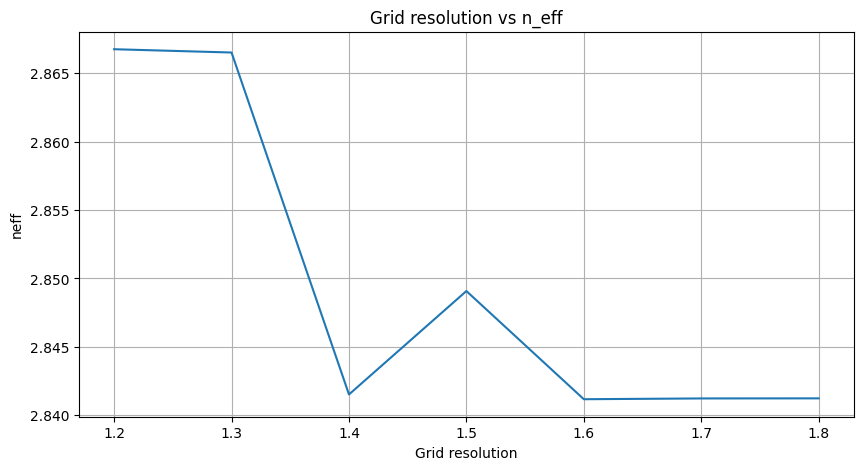

In [ ]:
#opción 1: grid_res = 50

n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []
print(grid_resolution)

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=220 * nm, # MMI Body height 
        slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=50, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:12:11.329 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_d179133d4b478388.npz.
Fracción TE: [0.99999604 0.99998409]


array([2.84117606+2.13601869e-05j, 2.83806502+2.13935856e-05j])

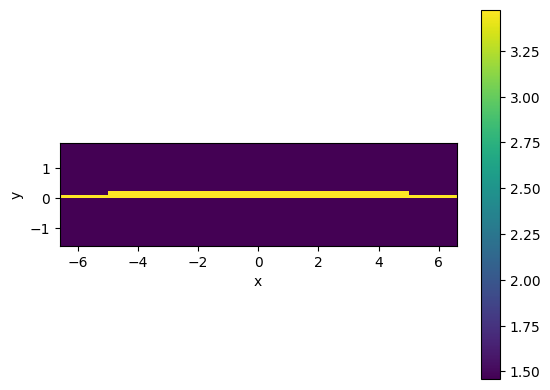

In [8]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=220 * nm, # MMI Body height 
    slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.6, # Parameters of the grid
    grid_resolution=50, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [12]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (f'L_pi = {L_pi}')

L_pi = 249.1121947703421


In [13]:
L_0 = (1 - 2*(0.72/10))*(1/3)*(3*L_pi)

print (f' L_0 = {L_0}')

 L_0 = 213.24003872341282


[20. 30. 40. 50. 60. 70. 80.]


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:48:46.958 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9117f47f7b6218ff.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:49:31.586 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_42f6f3b6401ce2f2.npz.


...

2026-03-31 18:51:15.939 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6a8e1f7e863bf292.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:51:48.563 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4784715d5b045c49.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:52:21.318 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e8fc01e7c1e91ea2.npz.


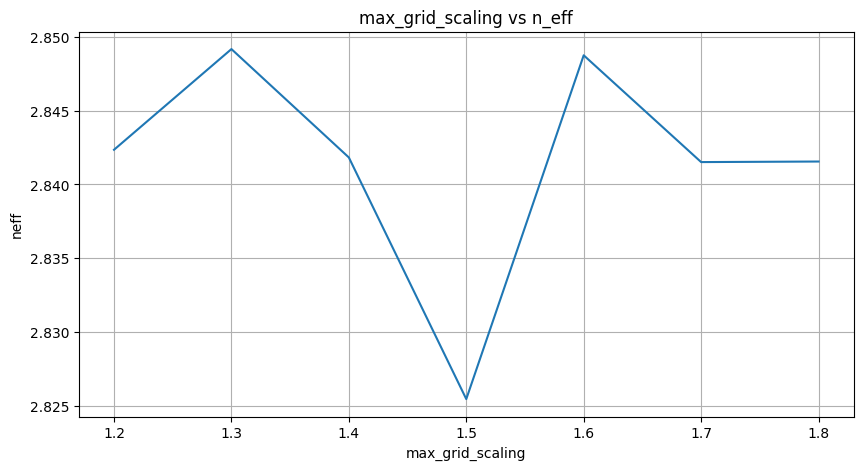

In [25]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []
print(grid_resolution)

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=220 * nm, # MMI Body height 
        slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=55, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:54:24.122 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_8a622266549ed5da.npz.
Fracción TE: [0.99999615 0.9999845 ]


array([2.84151265+2.13489436e-05j, 2.83840223+2.13822859e-05j])

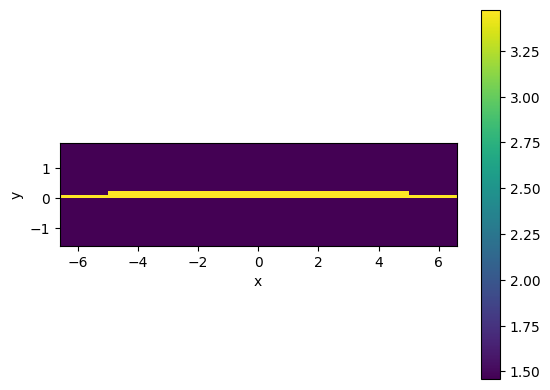

In [26]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=220 * nm, # MMI Body height 
    slab_thickness=90 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.7, # Parameters of the grid
    grid_resolution=55, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [27]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (f'L_pi = {L_pi}')

L_pi = 249.1626247214778


In [28]:
L_0 = (1 - 2*(0.72/10))*(1/3)*(3*L_pi)

print (f' L_0 = {L_0}')

 L_0 = 213.28320676158498


### WAVEGUIDE (450 nm width, 220 height)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:25:42.809 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_db7a43f98d148721.npz.


array(2.33508782)

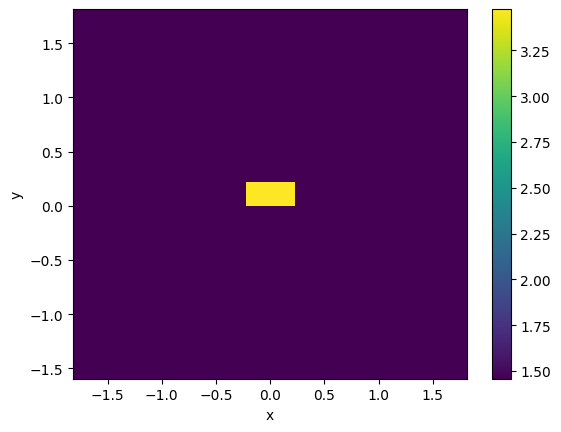

In [14]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.n_eff.real

He hecho el grid_scaling a partir de 100 pq en la simulación previa había hecho 10 a 100 y no había ninguna parte constante. 

2026-03-31 18:34:34.156 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c282adc049c36a4.npz.
2026-03-31 18:34:34.160 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_71fe0f46f30a95a5.npz.
2026-03-31 18:34:34.164 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9efc89966753b23b.npz.
2026-03-31 18:34:34.166 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f55b798012089b8f.npz.
2026-03-31 18:34:34.167 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0b18f4936378da21.npz.
2026-03-31 18:34:34.168 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0501cb4dcdd4dcd6.npz.
2026-03-31 18:34:34.173 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_051e7461e975c560.npz.


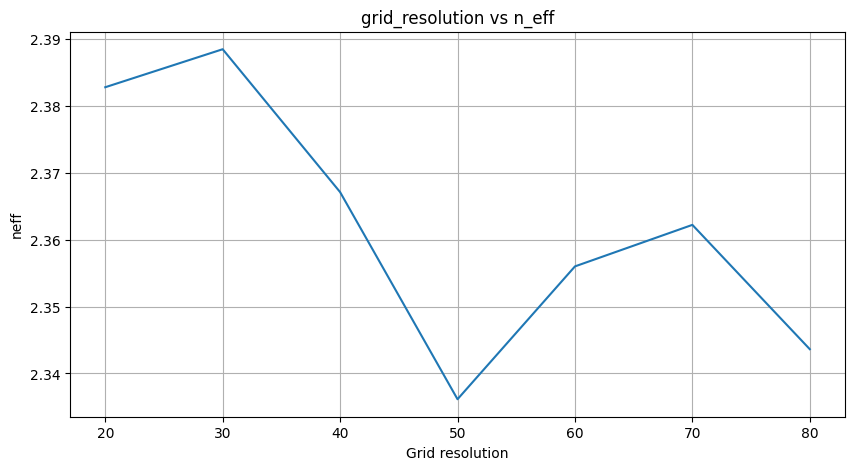

In [18]:
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=450 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find 
        max_grid_scaling=1.2, # Parameters of the grid 
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"grid_resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-03-31 18:35:09.859 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f55b798012089b8f.npz.
2026-03-31 18:35:09.861 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0094f4e2b3ad26ea.npz.
2026-03-31 18:35:09.864 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b14a11765917c909.npz.
2026-03-31 18:35:09.866 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b25c161fe108a907.npz.
2026-03-31 18:35:09.867 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4a217271eade6fdf.npz.
2026-03-31 18:35:09.870 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9b6e6056af225b9c.npz.
2026-03-31 18:35:09.877 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e3053659e9fb0906.npz.


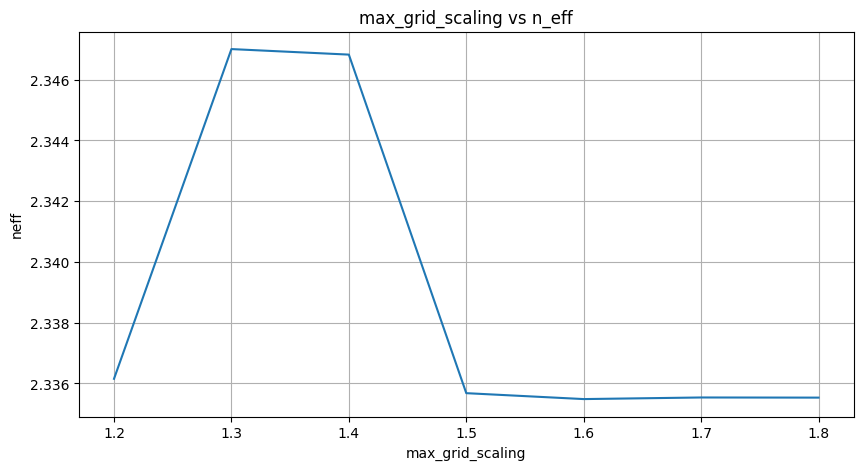

In [ ]:
#opción 1: 50 de grid res
n_steps = 7
max_grid_scaling= np.linspace(1.2,1.8,n_steps)

res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=450 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find 
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid 
        grid_resolution=50, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-03-31 18:40:42.510 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4e2811e051066c6a.npz.


array(2.3356317)

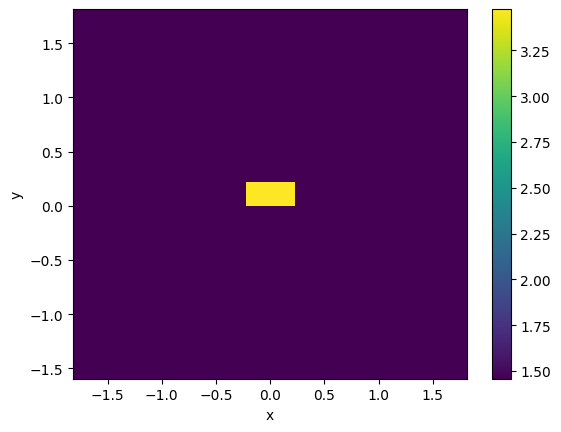

In [21]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.55, # Parameters of the grid 
    grid_resolution=50, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.n_eff.real

2026-03-31 18:42:06.384 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_135b42b5a2c6d568.npz.
2026-03-31 18:42:06.387 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bce9a9ec1c1c64d0.npz.
2026-03-31 18:42:06.388 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3b698d4bf907f9a4.npz.
2026-03-31 18:42:06.392 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_96e39e925de1c3b2.npz.
2026-03-31 18:42:06.397 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6910d3537f1a6ccb.npz.
2026-03-31 18:42:06.398 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_37ef202d88816f97.npz.
2026-03-31 18:42:06.399 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8d101e575eee486c.npz.


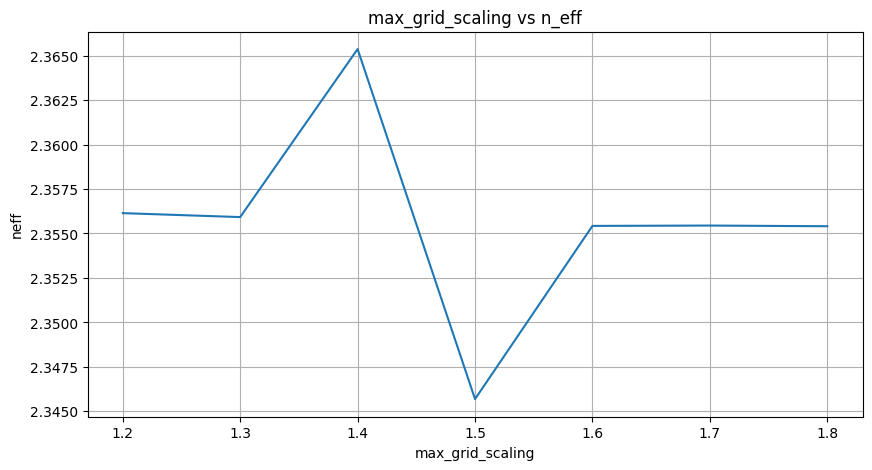

In [23]:
#opción 2: 45 de grid res
n_steps = 7
max_grid_scaling= np.linspace(1.2,1.8,n_steps)

res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=450 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find 
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid 
        grid_resolution=45, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)


plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

2026-03-31 18:46:00.750 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6910d3537f1a6ccb.npz.


array(2.35542716)

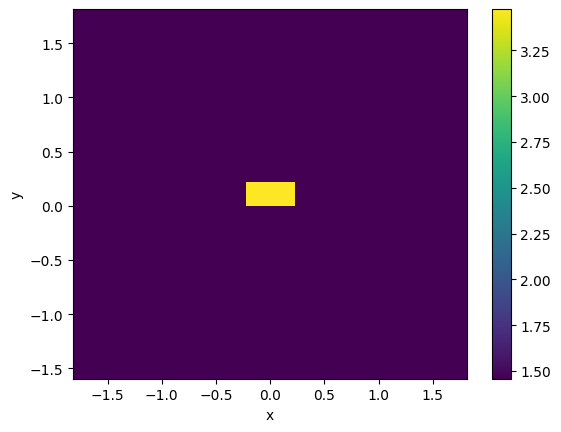

In [24]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.6, # Parameters of the grid 
    grid_resolution=45, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.n_eff.real